explore dataset

In [1]:
from matplotlib.widgets import Slider
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

In [2]:
path = "dataset/BraTS20_Training_004/BraTS20_Training_004_flair.nii"

In [3]:
img = nib.load(path)

In [4]:
print("shape:", img.shape)
print("voxel size:", img.header.get_zooms()) 
print("data type:", img.get_data_dtype())

shape: (240, 240, 155)
voxel size: (1.0, 1.0, 1.0)
data type: int16


In [5]:
data = img.get_fdata()
print("value range:", data.min(), "–", data.max())

value range: 0.0 – 757.0


display image

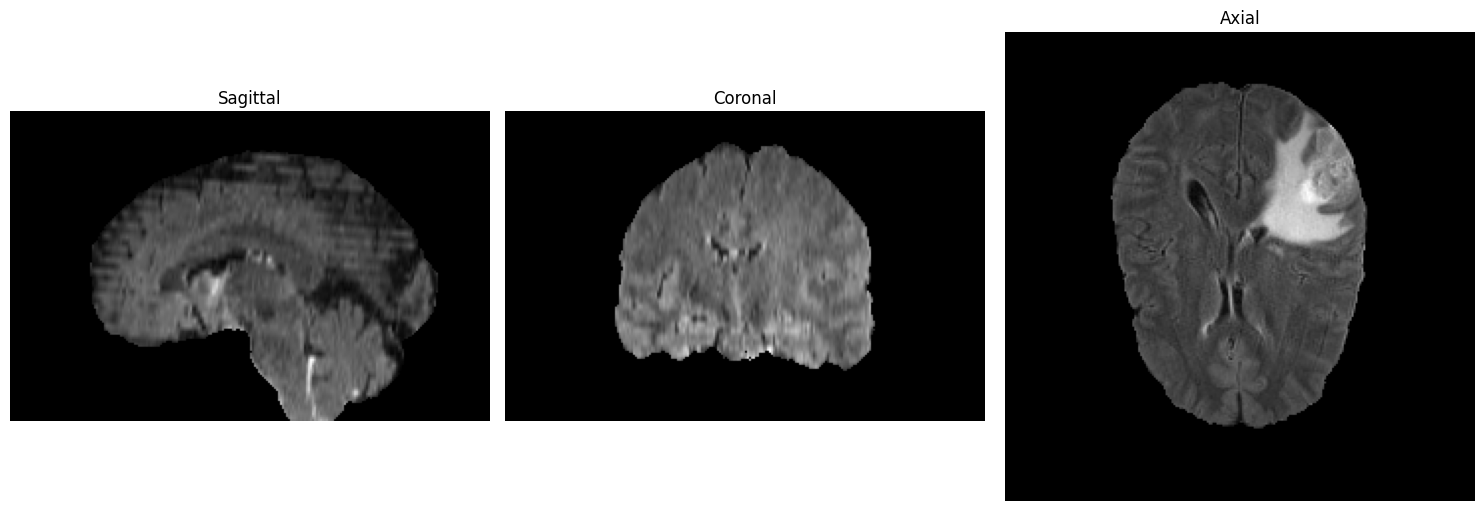

In [6]:
data = nib.load(path).get_fdata()

# pick middle slice from each axis
slice_ax  = data[data.shape[0]//2, :, :]   # sagittal
slice_cor = data[:, data.shape[1]//2, :]   # coronal
slice_axi = data[:, :, data.shape[2]//2]   # axial (most common view)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Sagittal", "Coronal", "Axial"]
slices = [slice_ax, slice_cor, slice_axi]

for ax, sl, title in zip(axes, slices, titles):
    ax.imshow(sl.T, cmap="gray", origin="lower")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig("brain_views.png", dpi=150)
plt.show()

In [7]:
%matplotlib widget

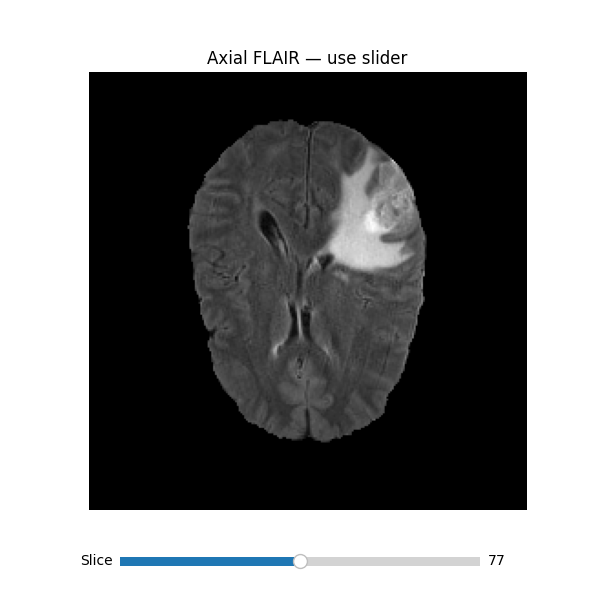

In [8]:
data = nib.load(path).get_fdata()
n_slices = data.shape[2]

fig, ax = plt.subplots(figsize=(6, 6))
plt.subplots_adjust(bottom=0.15)

im = ax.imshow(data[:, :, n_slices//2].T, cmap="gray", origin="lower")
ax.set_title("Axial FLAIR — use slider")
ax.axis("off")

ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
slider = Slider(ax_slider, "Slice", 0, n_slices - 1,
                valinit=n_slices // 2, valstep=1)

def update(val):
    im.set_data(data[:, :, int(slider.val)].T)
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

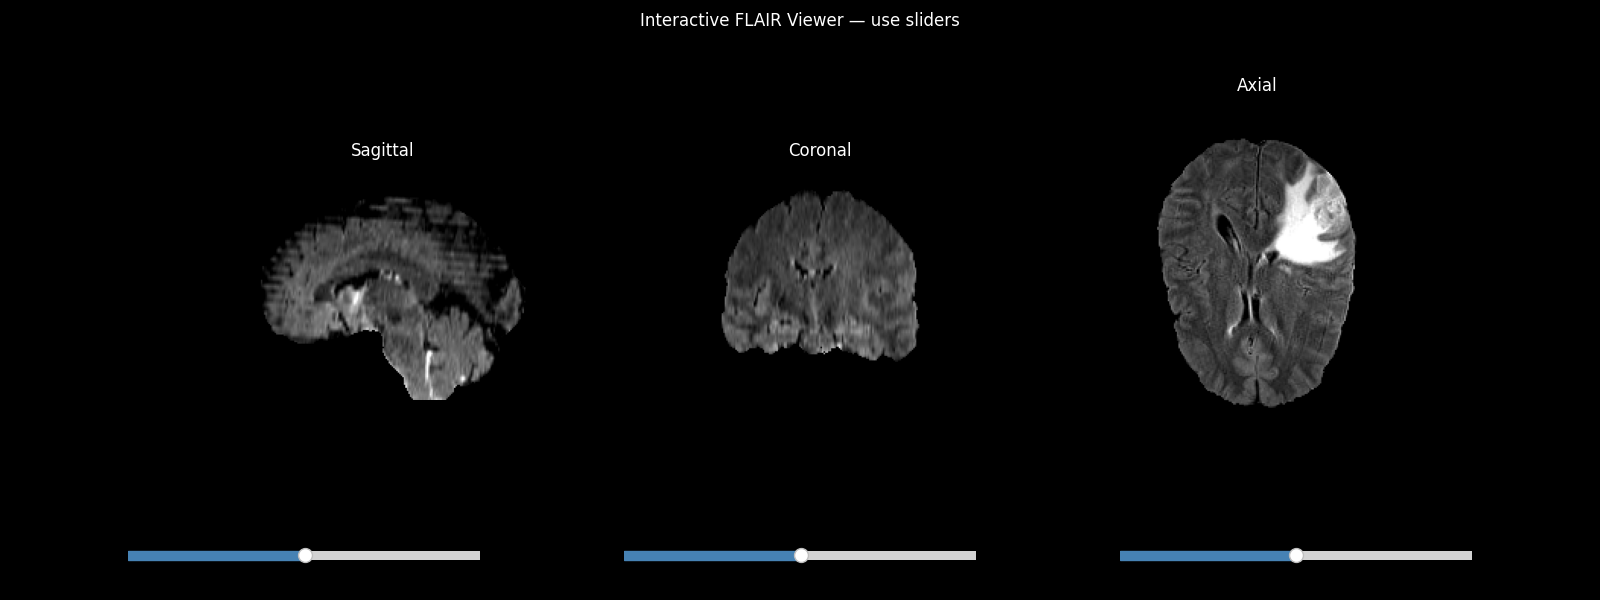

In [9]:

data = img.get_fdata()

p1, p99 = np.percentile(data[data > 0], [1, 99])   # ignore background (0s)
data_clipped = np.clip(data, p1, p99)
data_norm    = (data_clipped - p1) / (p99 - p1)

def get_slice(volume, axis, idx):
    if axis == 0:   return np.rot90(volume[idx, :, :])
    elif axis == 1: return np.rot90(volume[:, idx, :])
    else:           return np.rot90(volume[:, :, idx])


fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor="black")
plt.subplots_adjust(bottom=0.18, hspace=0.05)
fig.suptitle("Interactive FLAIR Viewer — use sliders", color="white", fontsize=12)

# Initial middle slices
init = [s // 2 for s in data_norm.shape]
ims  = [axes[i].imshow(get_slice(data_norm, i, init[i]), cmap="gray", vmin=0, vmax=1) for i in range(3)]

labels = ["Sagittal", "Coronal", "Axial"]
for ax, label in zip(axes, labels):
    ax.set_title(label, color="white")
    ax.axis("off")

slider_axes = [plt.axes([0.08 + i*0.31, 0.06, 0.22, 0.03]) for i in range(3)]
sliders = [
    Slider(slider_axes[i], labels[i][0], 0, data_norm.shape[i] - 1,
           valinit=init[i], valstep=1, color="steelblue")
    for i in range(3)
]

def update(_):
    for i, sl in enumerate(sliders):
        ims[i].set_data(get_slice(data_norm, i, int(sl.val)))
    fig.canvas.draw_idle()

for sl in sliders:
    sl.on_changed(update)

plt.show()